# Jaguar Karaoke Business Analytics
**Jun Kang | Data Analyst**  
*Berkeley & Oakland Locations — March 2026*

---

## Project Overview

This notebook analyzes reservation data from Jaguar Karaoke, a private-room karaoke business operating across two Bay Area locations (Berkeley and Oakland). The goal is to identify demand patterns, room utilization inefficiencies, and actionable opportunities for operational improvement.

**Key Findings:**
- Peak reservation demand occurs between **8PM–11PM**, with Oakland peaking earlier (7–9PM) and Berkeley later (9–11PM)
- Overall room utilization is low (~7% Berkeley, ~13.5% Oakland) based on reservation data alone
- Walk-in customers represent the **majority of actual traffic** — reservation data significantly underestimates true demand
- Most booked sessions last **2–3 hours**, aligning with the standard pricing structure
- Early evening slots (6–7PM) are consistently underutilized across both locations

**Data Note:** All analysis is based on reservation records only. Walk-in customers are not captured in this dataset, which limits utilization and demand estimates. Recommendations account for this gap.


## Business Overview

This project analyzes reservation data from a private-room karaoke business with two locations in Berkeley and Oakland, California. The business offers multiple room types with varying capacities and operates daily from 6 PM to 2 AM.

Pricing is based on group size and duration, with additional revenue generated from beverages and snacks.

The goal of this analysis is to understand demand patterns, room utilization, and operational efficiency, and to identify opportunities to improve performance.

---

## Project Objectives

This analysis focuses on three key areas:

**1. Demand & Revenue Drivers**
- Identify peak hours and key factors influencing usage (e.g., group size, duration)
- Evaluate how demand varies across locations

**2. Operational Efficiency**
- Measure room utilization across time
- Identify underutilized periods and capacity gaps

**3. Data Limitations & Insights**
- Assess limitations in the current data (e.g., no walk-in tracking, no item-level sales)
- Translate data gaps into business impact and improvement opportunities

## Data Overview

The dataset consists of reservation-level records from two locations (Berkeley and Oakland). Each row represents a single booking.

Key variables include:
- Date: reservation date
- Start / End Time: booking time window
- Duration: length of session (engineered)
- Group Size: number of customers per reservation
- Location: Berkeley or Oakland
- Room: room identifier or type
- Total Spend: total amount spent per group (when available)

### Data Challenges
- Inconsistent time formats required parsing and standardization
- Missing end times in some cases required estimation using duration
- No customer identifiers → cannot track repeat behavior
- No item-level data → cannot analyze drink/food preferences
- Walk-in customers not captured → utilization is underestimated

In [13]:
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt

## Data Cleaning

The raw reservation data required several preprocessing steps before analysis:

- Standardized inconsistent column names across Berkeley and Oakland datasets  
- Removed unnecessary columns generated during export  
- Combined datasets into a single dataframe with a location indicator  
- Forward-filled missing dates to maintain continuity  
- Removed rows with missing check-in times  

These steps ensure consistency and allow for accurate time-based analysis.

In [14]:
# Load data
oak = pd.read_csv('Reservation_Jaguar  - March Oakland.csv')
berk = pd.read_csv('Reservation_Jaguar  - March Berkeley.csv')

# Standardize column names before combining
oak = oak.rename(columns={'Oakland': 'Check_in'})
berk = berk.rename(columns={'Check-in': 'Check_in'})

# Drop junk columns from Berkeley
berk = berk.drop(columns=['Unnamed: 7', 'Unnamed: 8'])

# Add location
oak['location'] = 'Oakland'
berk['location'] = 'Berkeley'

# Combine
df = pd.concat([oak, berk], ignore_index=True)

# Forward fill dates
df['Date'] = df['Date'].ffill()

# Drop rows without check-in
df = df[df['Check_in'].notna()].copy()

In [15]:
print(df.info())
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 215 entries, 0 to 374
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Date           215 non-null    object
 1   Check_in       215 non-null    object
 2   Room #         112 non-null    object
 3   Confirmed?     50 non-null     object
 4   Date Received  104 non-null    object
 5   by whom        151 non-null    object
 6   Notes          45 non-null     object
 7   location       215 non-null    object
dtypes: object(8)
memory usage: 15.1+ KB
None
Date               0
Check_in           0
Room #           103
Confirmed?       165
Date Received    111
by whom           64
Notes            170
location           0
dtype: int64


### Data Quality Check

- Core fields such as date and check-in time are complete  
- Several operational fields (e.g., room assignment, confirmation status, notes) contain significant missing values  
- Missing values suggest inconsistent data entry practices and limit deeper operational analysis  

## Feature Engineering

To make the reservation data analyzable, I transformed unstructured booking text into structured variables such as start time, end time, group size, phone number, duration, and weekday. I also converted ambiguous evening and overnight times into a consistent business hour scale to support demand and utilization analysis.

In [16]:
def parse_checkin(text):
    text = str(text).strip()

    # normalize weird formats
    text = text.replace('~', '-')
    text = re.sub(r'(\d)\s+(\d{2})', r'\1:\2', text)

    # special case like 3:30/4:30-6:30
    slash_match = re.search(r'(\d{1,2}:\d{2})/(\d{1,2}:\d{2})-(\d{1,2}:\d{2})', text)
    if slash_match:
        start = slash_match.group(2)
        end = slash_match.group(3)
    else:
        time_match = re.search(r'(\d{1,2}:\d{2})(?:-(\d{1,2}:\d{2}))?', text)
        start = time_match.group(1) if time_match else None
        end = time_match.group(2) if time_match and time_match.group(2) else None

    group_match = re.search(r'(\d+)-?(\d+)?ppl', text)
    if group_match:
        g1 = int(group_match.group(1))
        g2 = group_match.group(2)
        group_size = (g1 + int(g2)) / 2 if g2 else g1
    else:
        group_size = None

    phone_match = re.search(r'\d{3}-\d{3}-\d{4}', text)
    phone = phone_match.group(0) if phone_match else None

    return pd.Series({
        'start_time': start,
        'end_time': end,
        'group_size': group_size,
        'phone': phone
    })

In [17]:
parsed = df['Check_in'].apply(parse_checkin)
df = pd.concat([df, parsed], axis=1)

### Time Standardization for Business Hours

Because Jaguar operates during evening and overnight hours (6 PM–2 AM), raw timestamps can be ambiguous and cross midnight.

To address this, I converted all times into a continuous "business hour" scale, where:
- 6 PM = 18
- Midnight = 24
- 2 AM = 26

This allows accurate calculation of session duration and enables consistent time-based analysis.

In [18]:
# Because the business operates in the evening and late night hours,
# I adjusted time parsing logic to correctly interpret ambiguous timestamps and handle overnight sessions.

def to_business_hour(t):
    if pd.isna(t) or t is None:
        return None
    
    t = str(t).strip()
    hour, minute = map(int, t.split(':'))
    value = hour + minute / 60

    # 3 PM – 11 PM
    if 3 <= hour <= 11:
        value += 12
    
    # midnight (12:00 AM)
    elif hour == 12:
        value = 24 + minute / 60
    
    # 1 AM – 2:59 AM
    elif 0 <= hour < 3:
        value += 24
    
    return value

df['start_hour_num'] = df['start_time'].apply(to_business_hour)
df['end_hour_num'] = df['end_time'].apply(to_business_hour)

df['duration_hours'] = df['end_hour_num'] - df['start_hour_num']
df.loc[df['duration_hours'] <= 0, 'duration_hours'] = None

df[['Check_in', 'start_time', 'end_time', 'start_hour_num', 'end_hour_num', 'duration_hours']].head(15)

,Check_in,start_time,end_time,start_hour_num,end_hour_num,duration_hours
0,3:30/4:30-6:30 15ppl Lori 609-498-4868,4:30,6:30,16.5,18.5,2.0
1,6:30-8:00 10ppl Madison 978-994-3486,6:30,8:00,18.5,20.0,1.5
2,10:00-2:00 14-15ppl Mera Maselli 510-755-9703,10:00,2:00,22.0,26.0,4.0
3,8:30-11:30 8-10ppl Nick 603-848-4064,8:30,11:30,20.5,23.5,3.0
4,7:00 4ppl Julia 510-561-5030,7:00,None,19.0,NaN,NaN
8,8:00 3-4ppl Jade 650-303-1356,8:00,None,20.0,NaN,NaN
9,9:00 8-10ppl Story 303-862-0015,9:00,None,21.0,NaN,NaN
15,9:30-11:30 8ppl Emily Murffy 925-594-9491,9:30,11:30,21.5,23.5,2.0
16,9:30-11:30 10-12ppl Mamu 628-205-7863,9:30,11:30,21.5,23.5,2.0
17,8:30-11:30 12ppl Omar 415-859-8065,8:30,11:30,20.5,23.5,3.0


In [19]:
df['Date_clean'] = df['Date'].astype(str).str.extract(r'(\d{2}/\d{2})')
df['Date_parsed'] = pd.to_datetime(df['Date_clean'], format='%m/%d', errors='coerce')
df['weekday'] = df['Date_parsed'].dt.day_name()

In [20]:
df.groupby('location')['Date_clean'].nunique()

location
Berkeley    16
Oakland     18
Name: Date_clean, dtype: int64

## Section: Analysis

In [21]:
# Convert float hour to integer for grouping (e.g. 20.5 → 20)
df['start_hour'] = df['start_hour_num'].apply(lambda x: int(x) if pd.notna(x) else None)

## Section: Peak Hour Demand

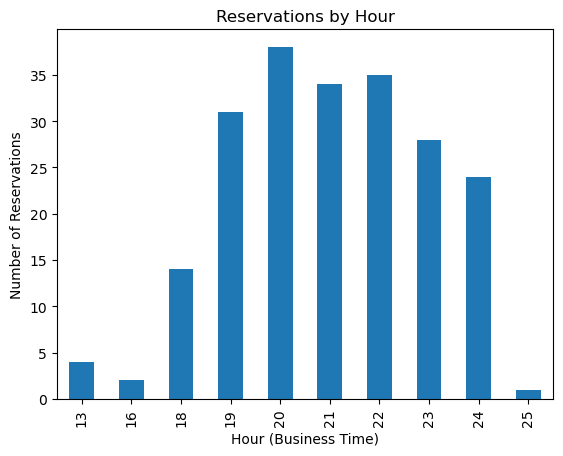

In [22]:
hour_counts = df['start_hour'].value_counts().sort_index()
hour_counts.index = hour_counts.index.astype(int)

hour_counts.plot(kind='bar')
plt.title('Reservations by Hour')
plt.xlabel('Hour (Business Time)')
plt.ylabel('Number of Reservations')
plt.show()

## Insight: Demand Patterns

> Reservation demand is heavily concentrated between 8 PM and 11 PM, with a clear peak around 9–10 PM. Early hours (6–7 PM) show relatively low utilization, and demand drops significantly after midnight.

> This suggests that the business operates with strong peak-hour pressure but underutilized capacity during early evening hours.

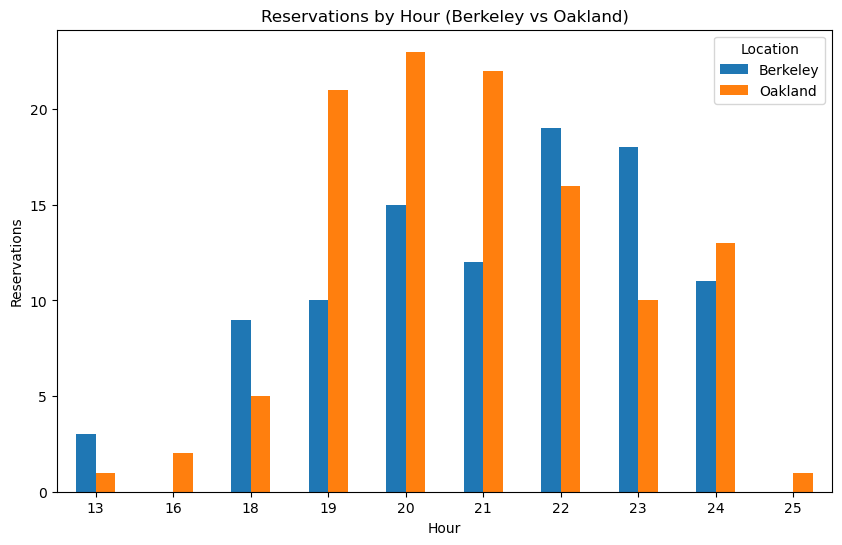

In [23]:
location_hour = df.groupby(['location', 'start_hour']).size().unstack(fill_value=0)
location_hour.columns = location_hour.columns.astype(int)

location_hour.T.plot(kind='bar', figsize=(10,6))

plt.title('Reservations by Hour (Berkeley vs Oakland)')
plt.xlabel('Hour')
plt.ylabel('Reservations')
plt.xticks(rotation=0)
plt.legend(title='Location')
plt.show()

## Insight: Demand Patterns by Location

Reservation timing differs significantly between locations:

- **Oakland** peaks between **7–9 PM**, with stronger early evening demand
- **Berkeley** peaks later, around **10–11 PM**, likely reflecting student-driven late-night activity
- Both locations drop sharply after midnight
- Early evening (6–7 PM) is consistently underutilized across both locations

These differences have direct implications for staffing schedules, promotional timing, and opening hour decisions by location. See Recommendations section for specific actions.

## Section: Utilization

In [24]:
booked_hours = df.groupby('location')['duration_hours'].sum()

days = df.groupby('location')['Date_clean'].nunique()

room_counts = {
    'Berkeley': 13,
    'Oakland': 9
}

util = pd.DataFrame({
    'booked_hours': booked_hours,
    'days': days
})

util['rooms'] = util.index.map(room_counts)
# 8 hour operation from 6pm to 2am
util['capacity_hours'] = util['days'] * util['rooms'] * 8
util['utilization_rate'] = util['booked_hours'] / util['capacity_hours']

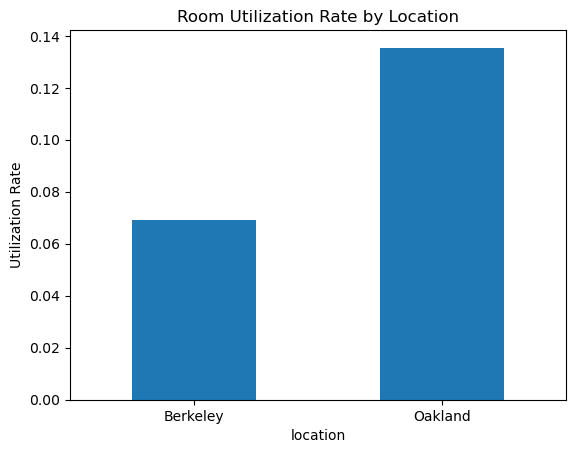

In [25]:
util['utilization_rate'].plot(kind='bar')
plt.title('Room Utilization Rate by Location')
plt.ylabel('Utilization Rate')
plt.xticks(rotation=0)
plt.show()

## Insight: Capacity Utilization

Both locations show low overall utilization — Berkeley at ~7% and Oakland at ~13.5% of total available room capacity. Demand is heavily concentrated in a narrow late-evening window, leaving early hours largely unused.

**Note:** These figures are conservative estimates based on reservation data only and do not capture walk-in traffic, which represents the majority of actual customers at both locations.

# Section: Heatmap Analysis

In [26]:
# making sure the source rows are clean
# filter out bad rows:
heat_df = df.copy()

heat_df = heat_df[
    heat_df['start_hour_num'].notna() &
    heat_df['duration_hours'].notna() &
    (heat_df['duration_hours'] > 0)
].copy()

# create a usable end hour:
heat_df['end_hour_filled'] = heat_df['end_hour_num'].fillna(
    heat_df['start_hour_num'] + heat_df['duration_hours']
)

In [27]:
# expand each reservation into hourly slots, but keep the date
rows = []

for _, row in heat_df.iterrows():
    start = int(row['start_hour_num'])
    end = int(row['end_hour_filled'])

    if end > start:
        for h in range(start, end):
            rows.append({
                'location': row['location'],
                'date': row['Date_clean'],
                'hour': h
            })

hourly_df = pd.DataFrame(rows)

In [28]:
# count rooms occupied by date and hour

daily_hour_counts = (
    hourly_df.groupby(['location', 'date', 'hour'])
    .size()
    .reset_index(name='rooms_occupied')
)

# each row means:
# For this location, on this specific date, at this specific hour, how many reservations were occupying rooms.

In [29]:
# average across days

avg_hour_counts = (
    daily_hour_counts.groupby(['location', 'hour'])['rooms_occupied']
    .mean()
    .unstack(fill_value=0)
)

In [30]:
# convert to utilization rate

room_counts = {'Berkeley': 13, 'Oakland': 9}

avg_util = avg_hour_counts.astype(float).copy()

for loc in avg_util.index:
    avg_util.loc[loc] = avg_util.loc[loc] / room_counts[loc]

avg_util = avg_util.clip(upper=1)

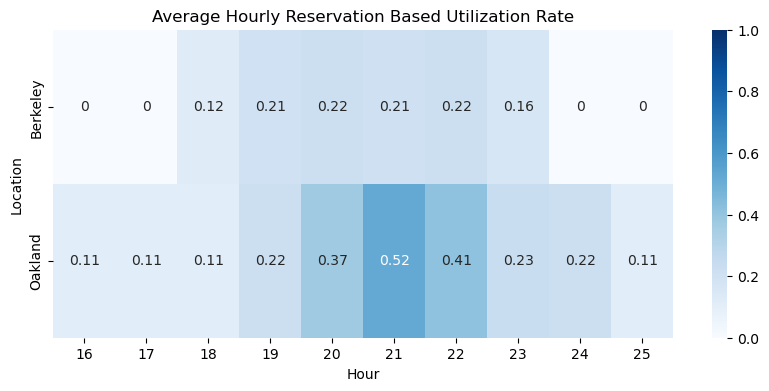

In [31]:
#Heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(avg_util, annot=True, cmap='Blues', vmin=0, vmax=1)
plt.title('Average Hourly Reservation Based Utilization Rate')
plt.xlabel('Hour')
plt.ylabel('Location')
plt.show()

## Insight: Hourly Utilization Heatmap

Each cell shows the average % of rooms occupied by reservations at that hour.

**Key findings:**

- **Oakland** shows strong reservation demand, peaking at ~52% occupancy around 9–10PM — high for reservation-only data
- **Berkeley** reservation demand is weak (~20–22% max), consistent with its walk-in driven model
- Both locations share a clear peak window of **8PM–10PM**
- Early hours (6–7PM) are near zero across both locations

**Important:** These figures capture reservation traffic only. Walk-in customers — who represent the majority of actual traffic, especially in Berkeley — are not reflected here, meaning true utilization is significantly higher.

**Operational implication:** Oakland's structured group demand makes it better suited for dynamic pricing and online booking incentives. Berkeley's spontaneous walk-in model requires a different approach focused on in-person conversion.

## Reservation Behavior Analysis

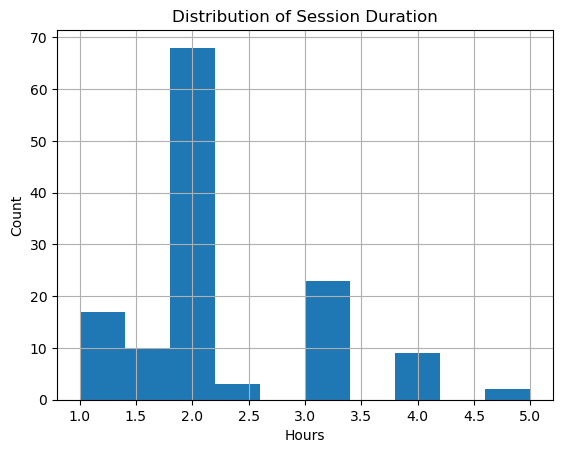

In [32]:
# Average session duration by group size
df.groupby('group_size')['duration_hours'].mean()

# Average group size by start hour
df.groupby('start_hour')['group_size'].mean()

# Distribution of session durations
df['duration_hours'].hist()
plt.title('Distribution of Session Duration')
plt.xlabel('Hours')
plt.ylabel('Count')
plt.show()

Analysis of group size and session duration patterns within the reservation dataset.

**Key findings:**

- Larger groups (8+ people) tend to book sessions of 2–3 hours, aligning with the standard pricing structure
- Early evening reservations (6–7PM) skew toward larger, pre-planned parties — consistent with the low spontaneous demand in that window
- Session duration clusters tightly around 2–3 hours across both locations

**Important caveat:** Reservation data is biased toward larger groups. Walk-in customers — who are likely smaller parties — are not captured, meaning this analysis reflects planned group behavior rather than typical customer behavior.

## Section: Data Limitations & Improvement Opportunities

### Current Limitations
- No-shows tracked via cell color only — not exportable or analyzable
- No customer identifiers, revenue data, or item-level purchases
- Berkeley and Oakland use different formats requiring significant preprocessing
- Reservation details (time, group size, contact) stored as unstructured text in a single field

### Recommended Data Improvements

1. **Add explicit no-show column** — replace color encoding with a binary `no_show` flag
2. **Standardize schema across locations** — align column names, date formats, room numbering
3. **Normalize reservation fields** — separate `start_time`, `end_time`, `group_size`, `customer_name`, `phone` into distinct columns
4. **Use 24-hour time format** — eliminates ambiguity in overnight sessions
5. **Capture revenue per reservation** — enables pricing analysis, revenue forecasting, and customer value tracking
6. **Add walk-in tracking** — even a simple hourly tally would dramatically improve demand visibility, especially for Berkeley

---

# Section: Actionable Recommendations

Based on the reservation data analysis and on-site operational knowledge, the following recommendations are prioritized by potential impact:

---

### 1. Extend Staffing on Friday & Saturday 9PM-11PM
**Finding:** Reservation demand peaks sharply between 9-11PM on weekends at both locations.  
**Recommendation:** Ensure full staffing coverage during this window. If rooms are consistently full, consider a waitlist system to capture overflow demand.  
**Expected impact:** Reduced customer wait times, improved experience during peak hours.

---

### 2. Introduce Early Evening Incentives (6-7PM)
**Finding:** Both locations show consistently low utilization in the 6-7PM window.  
**Recommendation:** Offer a discounted rate or package deal (e.g., "Happy Hour Karaoke") for sessions starting before 7PM. This smooths demand and increases overall revenue per operating day.  
**Expected impact:** Higher utilization in dead hours, potential to attract new customer segments.

---

### 3. Earlier Reservation Confirmation for Oakland
**Finding:** Reservation data shows Oakland peaking earlier (7-9PM) compared to 
Berkeley. Note: on-site experience suggests actual peak traffic (including walk-ins) 
may skew later toward 10PM-1AM — this would be confirmed with full operational data.  
**Recommendation:** Implement a confirmation call or text 24-48 hours before the 
reservation, specifically for Oakland Friday/Saturday bookings.  
**Expected impact:** Reduced no-show rate, better room allocation for walk-in customers.

---

### 4. Improve Daily Operations Data Structure
**Finding:** Jaguar already tracks daily operations including walk-ins via a revenue 
sheet (group size, room, start/end time, F&B total, payment method, tip). The current 
format works well for daily use but has three structural issues that limit analytical 
value:

1. **No session continuity tracking** — when customers extend their stay, a new row is 
added with no formal link to the original booking. Currently workers use informal group 
descriptors to connect rows, but these vary by individual. A simple fix would be 
assigning a session ID at check-in (e.g. room number + check-in time like "R5-2030") 
that gets reused on any extension rows — no customer identity needed.
2. **F&B recorded as a single total** — item-level purchases are not captured, making 
it impossible to analyze what customers are actually buying
3. **No machine-readable item tracking** — without a barcode reader or POS system, 
item-level data collection adds friction to staff workflow

**Recommendation:** 
- Introduce a standardized group ID system (e.g. room number + start time) to link 
extended sessions to the same visit
- Integrate a simple POS or tablet-based ordering system to capture item-level F&B data 
without adding manual work for staff

**Expected impact:** Enables revenue per session analysis, F&B attach rates by group 
type and hour, true utilization including walk-ins, and customer behavior patterns — 
transforming the daily sheet into a full analytics asset.

---

### 5. Evaluate Ancillary Revenue Opportunities
**Finding:** Customers frequently bring outside food and drinks with no current tracking or charge.  
**Recommendation:** While Jaguar's model intentionally prioritizes customer experience, optional drink packages (not mandatory corkage) could add revenue without disrupting the customer-friendly positioning.  
**Expected impact:** Incremental revenue upside with minimal friction if implemented optionally.

---

### 6. Introduce a Drink-Driven Revenue Stream
**Finding:** Current revenue relies almost entirely on room pricing. Customers frequently bring outside food and drinks, representing unmonetized consumption.  
**Recommendation:** Introduce optional drink bundles (e.g., "room + 2 soju" package) and consider happy hour pricing between 6–8PM to drive early evening traffic. This shifts the revenue model closer to industry standard where F&B drives margin.  
**Expected impact:** Increased per-customer spend, higher early-hour utilization, stronger overall revenue without raising room prices.

---

### 7. Explore Restaurant Partnership for Food & Beverage
**Finding:** Customers already bring outside food — the behavior exists and is normalized.  
**Recommendation:** Formalize this by partnering with nearby restaurants (delivery or pickup deals tied to room bookings). A commission-based referral or "order from X, get room discount" structure monetizes existing behavior without requiring kitchen infrastructure.  
**Expected impact:** Added revenue stream, enhanced customer experience, potential cross-promotion with local businesses.

---

### Summary Table

| Recommendation | Effort | Impact | Priority |
|---|---|---|---|
| Extend peak hour staffing | Low | High | High |
| Early evening incentives | Medium | Medium | High |
| Oakland confirmation calls | Low | Medium | Medium |
| Improve daily data structure | Medium | Very High | High |
| Ancillary revenue options | Medium | Medium | Medium |
| Drink-driven revenue stream | Medium | High | High |
| Restaurant partnership | Low | Medium | Medium |

**Note:** These recommendations are framed as optional improvements.
Jaguar's current model intentionally prioritizes customer experience over
revenue maximization — a deliberate strategic choice that likely drives
long-term loyalty over short-term profit.